In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,KFold
from sklearn.linear_model import Ridge,RidgeCV,Lasso,LassoCV,ElasticNet,ElasticNetCV,lasso_path,enet_path
from sklearn.cross_decomposition import PLSRegression
import statsmodels.api as sm 


In [2]:
oil_data = pd.read_csv(r'/Users/tymek/Desktop/Regression case studies/Oil Data.csv')
oil_data.shape

(418, 47)

In [3]:
X_raw = oil_data.iloc[:,2:47]
y = oil_data.iloc[:,1]

X_raw.head()

y.head()


0    18.65
1    17.75
2    18.30
3    18.68
4    19.44
Name: OP, dtype: float64

In [4]:
scaler = StandardScaler()
X_std = scaler.fit_transform(X_raw)
X_std.shape

(418, 45)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X_std, y, test_size= 0.2, random_state=0)


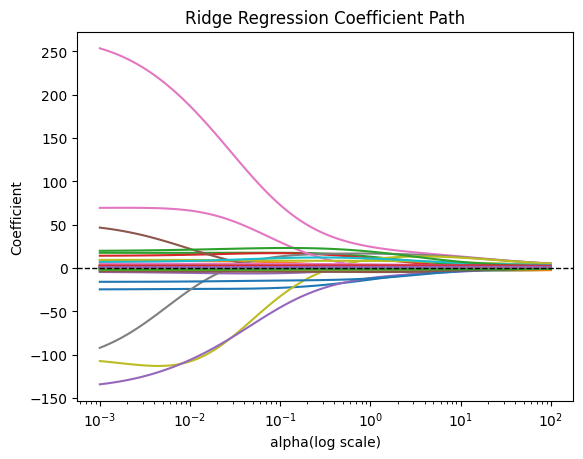

In [6]:
#Ridge Regression Coefficient Path

alpha_set = np.logspace(-3,2,100)
coefs = []
for alpha in alpha_set:
    reg_ridge = Ridge(alpha = alpha)
    reg_ridge.fit(X_train,y_train)
    coefs.append(reg_ridge.coef_)

ax = plt.gca()
ax.plot(alpha_set, coefs)
ax.set_xscale('log')
plt.xlabel('alpha(log scale)')
plt.ylabel('Coefficient')
plt.title('Ridge Regression Coefficient Path')
plt.axhline(0, linestyle = '--', linewidth = 1, color = 'k')

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.789e+03, tolerance: 9.668e+01
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.400e+04, tolerance: 9.668e+01
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the numb

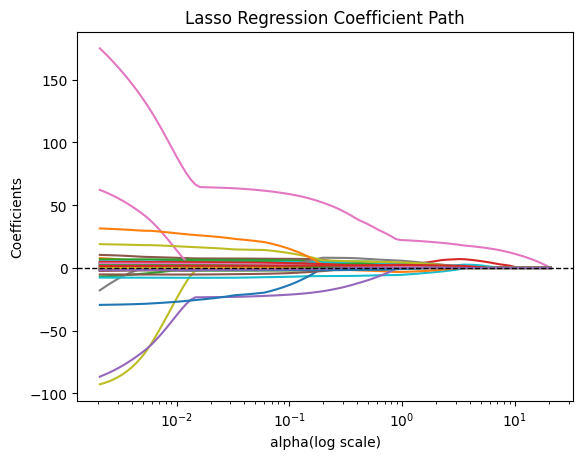

In [7]:
#Lasso Regression Coefficient Path 

alpha_set, coefs, _ = lasso_path(X_train,y_train,eps = 1e-4)

ax = plt.gca()
ax.plot(alpha_set, coefs.T)
ax.set_xscale('log')
plt.xlabel('alpha(log scale)')
plt.ylabel('Coefficients')
plt.title('Lasso Regression Coefficient Path')
plt.axhline(0, linestyle = '--', linewidth = 1, color = 'k')


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.945e+02, tolerance: 9.668e+01
  model = cd_fast.enet_coordinate_descent_gram(


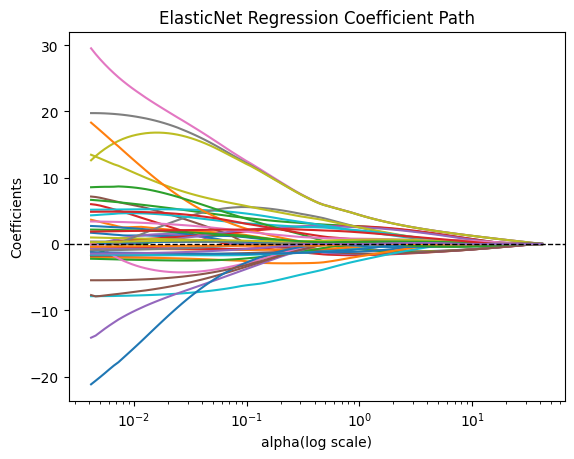

In [8]:
# Elastic Net Regression Coefficient Path

alpha_set, coefs, _ = enet_path(X_train, y_train, eps = 1e-4, l1_ratio=0.5)

ax = plt.gca()
ax.plot(alpha_set, coefs.T)
ax.set_xscale('log')
plt.xlabel('alpha(log scale)')
plt.ylabel('Coefficients')
plt.title('ElasticNet Regression Coefficient Path')
plt.axhline(0, linestyle = '--', linewidth = 1, color = 'k')



In [9]:
#Determine Optimal Alpha for Ridge Regression 

kfold = KFold(n_splits= 10, shuffle= True, random_state= 1)

reg1 = RidgeCV(alphas = alpha_set, cv = kfold)
reg1.fit(X_train,y_train)

reg1.alpha_

alphas = np.linspace(reg1.alpha_-5,reg1.alpha_+5,1000)
reg1_1 = RidgeCV(alphas = alphas, cv = kfold)
reg1_1.fit(X_train,y_train)

reg1_1.alpha_

np.float64(11.74255977123202)

In [10]:
#Ridge Regression: Leave-One-Out Cross-Validation (LOOCV)

reg1_2 = RidgeCV(alphas=alpha_set, store_cv_results=True)
reg1_2.fit(X_train, y_train)

reg1_2.alpha_

alphas_2 = np.linspace(reg1_2.alpha_ -5, reg1_2.alpha_ +5, 500)
reg1_3 = RidgeCV(alphas=alphas_2, store_cv_results=True)
reg1_3.fit(X_train, y_train)

reg1_3.alpha_


12.140945784745714

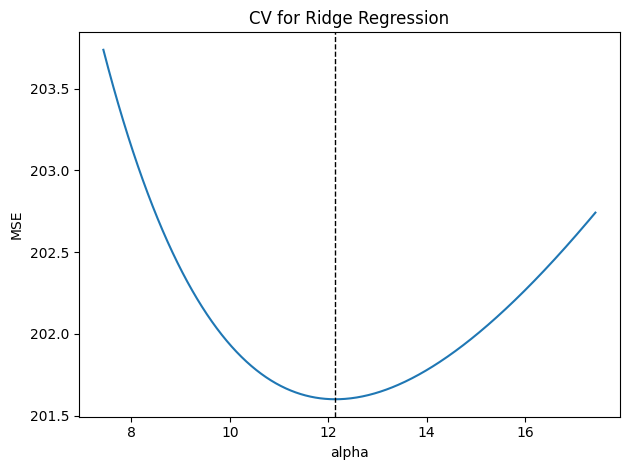

In [11]:
#Plot Ridge Regression Cross-Validation Curve

mse = np.mean(reg1_3.cv_results_, axis=0)
index_min = np.argmin(mse)
plt.plot(alphas_2,mse)
plt.axvline(alphas_2[index_min], linestyle = '--', linewidth = 1, color = 'k')
plt.xlabel('alpha')
plt.ylabel('MSE')
plt.title('CV for Ridge Regression')
plt.tight_layout()


In [12]:
#Lasso Regression: Cross-Validation to Find Optimal Alpha

reg2_1 = LassoCV(alphas=alpha_set)
reg2_1.fit(X_train,y_train)
reg2_1.alpha_

alphas_3 = np.linspace(max(reg2_1.alpha_ -5, 1e-4), reg2_1.alpha_ +5, 500)
reg2_2 = LassoCV(alphas=alphas_3)
reg2_2.fit(X_train,y_train)

reg2_2.alpha_

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.640e+02, tolerance: 2.222e+01
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.993e+02, tolerance: 2.222e+01
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the numb

np.float64(0.1443878815830095)

In [13]:
#Determine Optimal Alpha for Lasso Regression

kfold = KFold(n_splits= 10, shuffle= True, random_state= 1)

reg2 = LassoCV(alphas = alpha_set, cv = kfold)
reg2.fit(X_train,y_train)
reg2.alpha_

alphas = np.linspace(max(reg2.alpha_ -5, 1e-4), reg2.alpha_ +5, 500)
reg2_3 = LassoCV(alphas= alphas, cv = kfold)
reg2_3.fit(X_train,y_train)

reg2_3.alpha_

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.146e+02, tolerance: 2.430e+01
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.002e+02, tolerance: 2.430e+01
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the numb

np.float64(0.10246519201667947)

In [14]:
#cross-validation for elastic network regression

reg3_1 = ElasticNetCV(alphas= alpha_set, l1_ratio= [0.0001, 0.001, 0.01, 0.1, 0.5, 1])
reg3_1.fit(X_train,y_train)
reg3_1.alpha_

alphas_4 = np.linspace(reg3_1.alpha_-5, reg3_1.alpha_+5, 500)

reg3_2 = ElasticNetCV(alphas= alphas_3, l1_ratio=[0.0001, 0.001, 0.01, 0.1, 0.5, 1])
reg3_2.fit(X_train,y_train)
reg3_2.alpha_
reg3_2.l1_ratio_


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.935e+02, tolerance: 2.222e+01
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.411e+03, tolerance: 2.222e+01
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the numb

np.float64(0.0001)

In [15]:
#Determine Optimal Parameters for Elastic Net Regression

kfold = KFold(n_splits=10, shuffle=True, random_state=1)
reg3 = ElasticNetCV(alphas = alpha_set, cv=kfold, l1_ratio= [0.0001, 0.001, 0.01, 0.1, 0.5, 1])
reg3.fit(X_train,y_train)
reg3.alpha_

alphas = np.linspace(max(reg3.alpha_ - 5, 1e-4), reg3.alpha_ + 5, 500)
reg3_3 = ElasticNetCV(alphas=alphas, cv=kfold, l1_ratio=[0.0001, 0.001, 0.01, 0.1, 0.5, 1 ])

reg3_3.fit(X_train,y_train)
reg3_3.alpha_
reg3_3.l1_ratio_


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.440e+02, tolerance: 2.430e+01
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.325e+03, tolerance: 2.430e+01
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the numb

np.float64(0.0001)

In [16]:
#Model Evaluation: R² Score

#1.Ridge
reg1_3.score(X_test, y_test)

#2.Lasso
reg2_2.score(X_test, y_test)

#3.Elastic Net
reg3_2.score(X_test, y_test)

0.758120847033903

In [17]:
#Recursive (Rolling-Window) Forecasting for All Models

y1 = y.values

yhat = []
for i in range(0,118):
    reg_ridge_R = Ridge(alpha = 11.74)
    reg_ridge_R.fit(X_std[0+i:300+i,:],y1[0+i:300+i])
    z = reg_ridge_R.predict(X_std[300+i:300+i+1,:])
    yhat.append(float(z[0]))
yhat = np.array(yhat)
ytrue = y1[300:418]

SSE1 = 0 
for j in range(0,118):
    SSE1 = SSE1 + (yhat[j]-ytrue[j])**2

yhat = []
for i in range(0,118):
    reg_lasso_R = Lasso(alpha = 0.098)
    reg_lasso_R.fit(X_std[0+i:300+i,:],y1[0+i:300+i])
    z = reg_lasso_R.predict(X_std[300+i:300+i+1,:])
    yhat.append(float(z[0]))
yhat = np.array(yhat)
ytrue = y1[300:418]

SSE2 = 0
for j in range(0,118):
    SSE2 = SSE2 + (yhat[j]-ytrue[j])**2

yhat = []
for i in range(0,118):
    reg_en_R = ElasticNet(alpha = 0.045, l1_ratio = 0.5)
    reg_en_R.fit(X_std[0+i:300+i,:],y1[0+i:300+i])
    z = reg_en_R.predict(X_std[300+i:300+i+1,:])
    yhat.append(float(z[0]))
yhat = np.array(yhat)
ytrue = y1[300:418]

SSE3 = 0
for j in range(0,118):
    SSE3 = SSE3 + (yhat[j]-ytrue[j])**2



yhat = []
for i in range(0,118):
     reg_ridge_pls = PLSRegression(n_components=9)
     reg_ridge_pls.fit(X_std[0+i:300+i,:],y1[0+i:300+i])
     z = reg_ridge_pls.predict(X_std[300+i:300+i+1,:])
     yhat.append(float(z[0]))  
yhat = np.array(yhat)
ytrue = y1[300:418]

SSE4 = 0
for j in range(0,118):
    SSE4 = SSE4 + (yhat[j]-ytrue[j])**2


yhat = []
X_std = sm.add_constant(X_std)
for i in range(0,118):
     reg_ridge_ols = sm.OLS(y1[0+i:300+i], X_std[0+i:300+i,:])
     result = reg_ridge_ols.fit()
     z = result.predict(X_std[300+i:300+i+1,:])
     yhat.append(float(z[0]))
yhat = np.array(yhat)
ytrue = y1[300:418]

SSE5 = 0
for j in range(0,118):
     SSE5 = SSE5 + (yhat[j]-ytrue[j])**2

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.083e+01, tolerance: 2.159e+01
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.192e+01, tolerance: 2.194e+01
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iter

In [18]:
#Calculate the total sum of squares of deviations

TSS = 0
for j in range(0,118):
    TSS = TSS + (ytrue[j]-np.mean(ytrue))**2

RS1 = 1-SSE1/TSS
RS2 = 1-SSE2/TSS
RS3 = 1-SSE3/TSS

In [19]:
RS1, RS2, RS3

(np.float64(0.22500118389600898),
 np.float64(0.5101118163241789),
 np.float64(0.32595006587099096))

In [20]:
SSE1,SSE2,SSE3 

(np.float64(46082.19664223173),
 np.float64(29129.236256569642),
 np.float64(40079.676208238765))